# Leyenda - Livrable 3 : Captioning d'images (CNN + RNN)

### Groupe 2 - Projet Data Science (CESI A5)

---

## 0. Contexte metier - TouNum

**TouNum** est un projet de *numerisation patrimoniale* dont l'objectif est de
constituer automatiquement les **metadonnees** d'un fonds d'images numerisees
(photos, peintures, schemas, croquis, textes). Annoter manuellement des dizaines
de milliers d'images est trop couteux : on construit donc un **workflow automatise**
en trois etapes, chacune correspondant a un livrable du projet.

| Etape | Livrable | Role | Modele | Entree |
|-------|----------|------|--------|--------|
| **L1** | Livrable 1 | **Classification** (trier : photo / non-photo) | CNN *from scratch* (4 blocs Conv2D 32->64->128->256), Adam `1e-4` | 224x224 |
| **L2** | Livrable 2 | **Debruitage** des images degradees | Auto-encodeur **U-Net**, perte `0.85*MSE + 0.15*(1-SSIM)` | 256x256 |
| **L3** | **Livrable 3 (ce notebook)** | **Captioning** : generer une legende textuelle | **InceptionV3 (encodeur) + LSTM (decodeur)** | 299x299 |

Ce livrable final **integre les trois etapes** (section 9) : une image numerisee est
classee (L1), nettoyee si necessaire (L2), puis decrite par une legende (L3) qui
servira de metadonnee de recherche.

### Schema du pipeline complet

```
 +--------------------------------------------------------------------+
 |                      PIPELINE TouNum (workflow)                     |
 +--------------------------------------------------------------------+

        Image numerisee
             |
             v
   +-------------------+      Photo ?        +------------------+
   |  L1 : CLASSIF     | -----------------> |  Tri / routage    |
   |  CNN from scratch |                     +------------------+
   |  224 x 224        |
   +---------+---------+
             | (si image degradee / bruitee)
             v
   +-------------------+
   |  L2 : DEBRUITAGE  |   Auto-encodeur U-Net  (256x256, 0.85*MSE + 0.15*(1-SSIM))
   +---------+---------+
             | image nette
             v
   +-------------------+
   |  L3 : CAPTIONING  |   Encodeur InceptionV3 (299x299 -> 2048-d)
   |  CNN  +  RNN      |   Decodeur Embedding(256) + LSTM(256)
   +---------+---------+   ->  "<start> a dog runs on the grass <end>"
             |
             v
     Legende textuelle  (metadonnee indexable)
```

---
## 1. Imports & configuration centralisee

**QUOI** - Charger toutes les librairies et regrouper **tous les hyperparametres**
au meme endroit.
**POURQUOI** - Un point unique de configuration rend le notebook reproductible
(seed = 42) et facile a regler sans toucher au reste du code.
**COMMENT** - Une cellule d'imports, puis une cellule de configuration listant
chemins, dimensions et hyperparametres.

| Librairie | Role dans le livrable |
|-----------|-----------------------|
| `numpy`, `pandas` | manipulation des tableaux et des annotations |
| `matplotlib`, `PIL` | visualisation et chargement des images |
| `tqdm` | barre de progression (extraction des features) |
| `tensorflow` / `keras` | encodeur CNN, decodeur LSTM, entrainement |
| `InceptionV3` | encodeur d'images pre-entraine ImageNet (gele) |
| `nltk` (`bleu_score`) | metriques d'evaluation BLEU-1 / BLEU-2 |
| `scikit-learn` | decoupage train / validation |

In [1]:
# Librairies standard & data
import os, json, re, time, math, pickle, collections
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout, Add
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# NLP / metriques
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split

print('Imports OK - TensorFlow', tf.__version__)

Imports OK - TensorFlow 2.10.0


In [2]:
# -----------------------------------------------------------------
# CONFIGURATION CENTRALISEE
# Tous les chemins et hyperparametres du livrable 3 sont definis ici
# pour faciliter les reglages sans modifier le reste du code.
# -----------------------------------------------------------------

# --- Reproductibilite (seed globale) ---
import random
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# --- Chemins du projet (racine absolue, fixee pour cet environnement) ---
PROJECT_ROOT = Path(r"C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github")

DATA_RAW      = PROJECT_ROOT / 'data' / 'raw'
IMAGES_DIR    = DATA_RAW / 'train2014'
ANN_DIR       = DATA_RAW / 'annotations'
CAPTIONS_JSON = ANN_DIR / 'captions_train2014.json'
FEATURES_DIR  = PROJECT_ROOT / 'features'
MODELS_DIR    = PROJECT_ROOT / 'src' / 'models'
FIGURES_DIR   = PROJECT_ROOT / 'notebooks' / 'figures'
for d in (FEATURES_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

FEATURES_NPY  = FEATURES_DIR / 'image_features.npy'   # features CNN pre-extraites
MODEL_PATH    = MODELS_DIR / 'captioning_model.keras' # meilleur modele (ModelCheckpoint)
TOKENIZER_PKL = MODELS_DIR / 'captioning_tokenizer.pkl'

# --- Modeles des livrables precedents (workflow, section 9) ---
L1_MODEL_PATH = MODELS_DIR / 'cnn_scratch.keras'                # Classification (L1)
# Debruitage (L2) : le U-Net a ete sauvegarde avec Keras 3 (format .keras illisible
# par TF 2.10). On privilegie la version reconstruite en HDF5 (unet_model_tf210.h5),
# numeriquement identique a l'originale ; a defaut on retombe sur le .keras d'origine.
_L2_H5        = PROJECT_ROOT / 'notebooks' / 'unet_model_tf210.h5'
L2_MODEL_PATH = _L2_H5 if _L2_H5.exists() else PROJECT_ROOT / 'notebooks' / 'unet_model.keras'  # Debruitage (L2)

# --- Echantillonnage du dataset MS COCO ---
MAX_IMAGES = 8000          # sous-echantillon (images deja extraites dans data/raw/train2014/)

# --- Encodeur CNN (InceptionV3, gele) ---
IMG_SIZE    = 299          # taille d'entree InceptionV3
FEATURE_DIM = 2048         # dimension du vecteur de features (pooling='avg')
FEAT_BATCH  = 8            # taille de batch pour l'extraction des features

# --- Vocabulaire / texte ---
VOCAB_SIZE = 5000          # taille du vocabulaire (tokens speciaux inclus)
PAD_TOK, START_TOK, END_TOK, UNK_TOK = '<pad>', '<start>', '<end>', '<unk>'

# --- Decodeur RNN ---
EMBED_DIM   = 256          # dimension des embeddings de mots
LSTM_UNITS  = 256          # unites de la couche LSTM
DENSE_UNITS = 256          # unites de la couche de fusion
DROPOUT     = 0.5

# --- Entrainement ---
EPOCHS        = 15
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
VAL_SPLIT     = 0.2        # part des IMAGES reservee a la validation

# --- Evaluation ---
N_EVAL_IMAGES = 300        # nb d'images de validation pour le calcul du BLEU
N_SHOW        = 8          # nb d'exemples qualitatifs affiches

# --- GPU : croissance memoire (evite de saturer la GTX 1050) ---
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try: tf.config.experimental.set_memory_growth(g, True)
    except Exception as e: print('  set_memory_growth:', e)

print('Seed global     :', SEED)
print('GPU             :', [g.name for g in gpus] if gpus else 'aucun (CPU)')
print('Images dir      :', IMAGES_DIR, '(existe:', IMAGES_DIR.exists(), ')')
print('Captions JSON   :', CAPTIONS_JSON.exists())
print('Hyperparams     : vocab=%d  embed=%d  lstm=%d  epochs=%d  batch=%d  lr=%.0e'
      % (VOCAB_SIZE, EMBED_DIM, LSTM_UNITS, EPOCHS, BATCH_SIZE, LEARNING_RATE))

Seed global     : 42
GPU             : ['/physical_device:GPU:0']
Images dir      : C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github\data\raw\train2014 (existe: True )
Captions JSON   : True
Hyperparams     : vocab=5000  embed=256  lstm=256  epochs=15  batch=64  lr=1e-03


---
## 2. Chargement et exploration de MS COCO

**QUOI** - Charger les annotations COCO et les associer aux images du sous-echantillon.
**POURQUOI** - Comprendre le volume (images, legendes), la longueur des legendes et
le vocabulaire pour dimensionner correctement le modele.
**COMMENT** - Lecture du JSON `captions_train2014.json`, jointure avec les fichiers
reellement presents dans `data/raw/train2014/`, puis statistiques et exemples.

In [3]:
# Chargement des annotations COCO (legendes)
with open(CAPTIONS_JSON, encoding='utf-8') as f:
    coco = json.load(f)

# Correspondance image_id -> nom de fichier
id2file = {img['id']: img['file_name'] for img in coco['images']}

# On ne conserve que les legendes des images reellement extraites localement
available = set(os.listdir(IMAGES_DIR))
records = []
for a in coco['annotations']:
    fn = id2file.get(a['image_id'])
    if fn in available:
        records.append({'image_id': a['image_id'],
                        'file_name': fn,
                        'caption': a['caption'].strip()})
df = pd.DataFrame(records)

# Securite : si plus de MAX_IMAGES images, on tronque de maniere deterministe
keep = sorted(df['image_id'].unique())[:MAX_IMAGES]
df = df[df['image_id'].isin(set(keep))].reset_index(drop=True)

print('Images uniques :', df['image_id'].nunique())
print('Legendes       :', len(df))
df.head()

Images uniques : 8000
Legendes       : 40019


,image_id,file_name,caption
0,116100,COCO_train2014_000000116100.jpg,A panoramic view of a kitchen and all of its a...
1,116100,COCO_train2014_000000116100.jpg,A panoramic photo of a kitchen and dining room
2,302443,COCO_train2014_000000302443.jpg,Several metal balls sit in the sand near a gro...
3,18691,COCO_train2014_000000018691.jpg,A few people sit on a dim transportation system.
4,479495,COCO_train2014_000000479495.jpg,A bicycle is parked by a bench at night.


**Statistiques descriptives** : nombre de legendes par image et distribution des longueurs.

In [4]:
n_images = df['image_id'].nunique()
n_caps   = len(df)
df['n_words'] = df['caption'].str.split().apply(len)

print('Images               :', n_images)
print('Legendes             :', n_caps)
print('Legendes / image     : %.2f' % (n_caps / n_images))
print('Longueur (mots)      : min=%d  moy=%.1f  med=%d  max=%d'
      % (df['n_words'].min(), df['n_words'].mean(),
         df['n_words'].median(), df['n_words'].max()))
print()
print(df['n_words'].describe().round(2))

Images               : 8000
Legendes             : 40019
Legendes / image     : 5.00
Longueur (mots)      : min=7  moy=10.5  med=10  max=49

count    40019.00
mean        10.46
std          2.38
min          7.00
25%          9.00
50%         10.00
75%         11.00
max         49.00
Name: n_words, dtype: float64


**Histogramme des longueurs de legendes** - guide le choix de `MAX_LEN` (section 3).

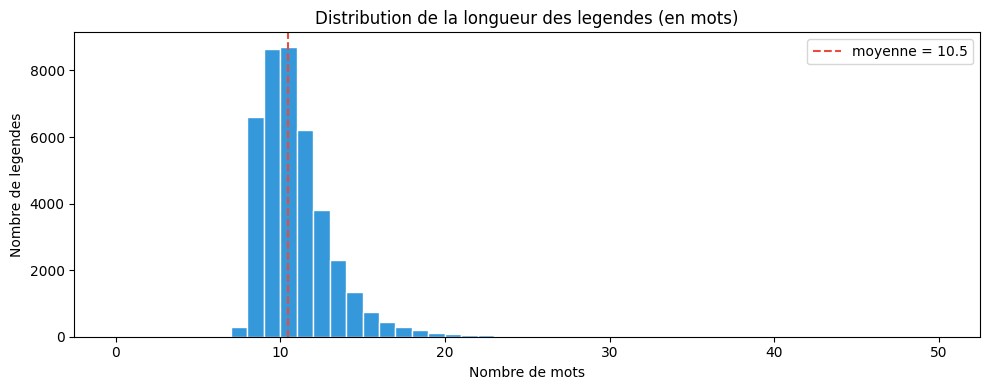

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['n_words'], bins=range(0, df['n_words'].max() + 2),
        color='#3498db', edgecolor='white')
ax.axvline(df['n_words'].mean(), color='#e74c3c', linestyle='--',
           label='moyenne = %.1f' % df['n_words'].mean())
ax.set_title("Distribution de la longueur des legendes (en mots)")
ax.set_xlabel('Nombre de mots'); ax.set_ylabel("Nombre de legendes")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / 'l3_hist_longueurs.png', dpi=120, bbox_inches='tight')
plt.show()

**Exemples** - quelques images avec l'une de leurs legendes de reference.

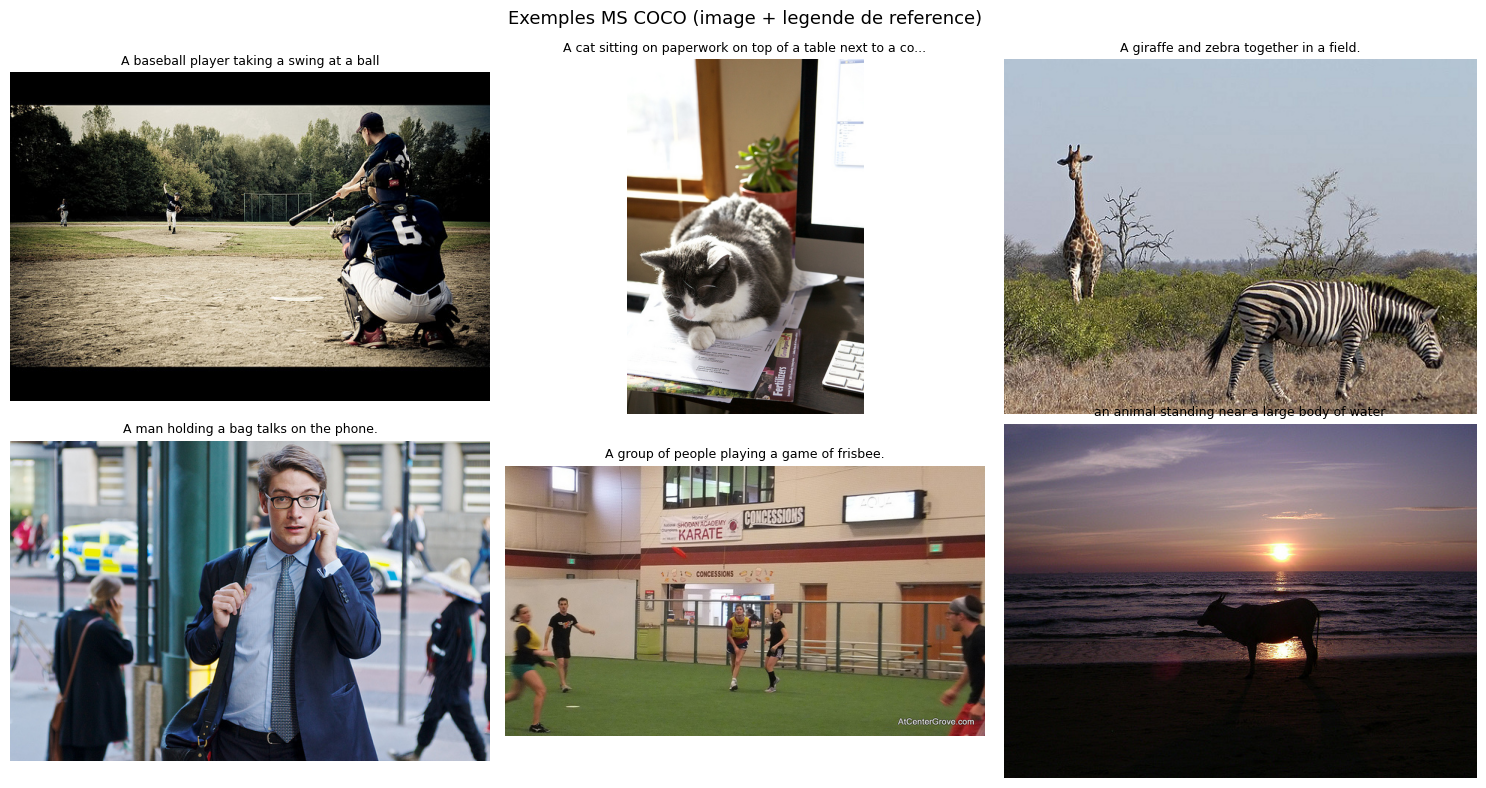

In [6]:
sample = df.drop_duplicates('image_id').sample(6, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(Image.open(IMAGES_DIR / row['file_name']))
    ax.axis('off')
    cap = row['caption']
    ax.set_title(cap if len(cap) < 60 else cap[:57] + '...', fontsize=9)
plt.suptitle("Exemples MS COCO (image + legende de reference)", fontsize=13)
plt.tight_layout(); plt.show()

---
## 3. Pretraitement du texte

**QUOI** - Nettoyer les legendes, construire le vocabulaire et encoder chaque
legende en sequence d'entiers.
**POURQUOI** - Le LSTM travaille sur des indices entiers ; il faut un vocabulaire
borne (5000 mots), des tokens speciaux (`<start>`, `<end>`, `<unk>`, `<pad>`) et
un *padding* a longueur fixe.
**COMMENT** - Normalisation (minuscules, ponctuation retiree), encadrement par
`<start>/<end>`, comptage des frequences, dictionnaires `word2idx` / `idx2word`.

In [7]:
# Nettoyage : minuscules, on ne garde que les lettres, espaces normalises
def clean_caption(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]+", ' ', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

df['clean'] = df['caption'].apply(clean_caption)
# Encadrement par les tokens de debut / fin de sequence
df['seq_text'] = START_TOK + ' ' + df['clean'] + ' ' + END_TOK

print('Avant :', df['caption'].iloc[0])
print('Apres :', df['seq_text'].iloc[0])

Avant : A panoramic view of a kitchen and all of its appliances.
Apres : <start> a panoramic view of a kitchen and all of its appliances <end>


**Construction du vocabulaire** : les `VOCAB_SIZE - 4` mots les plus frequents,
plus les 4 tokens speciaux. Les mots hors-vocabulaire seront remplaces par `<unk>`.

In [8]:
# Comptage des frequences sur le corpus nettoye
counter = collections.Counter()
for t in df['clean']:
    counter.update(t.split())

n_special   = 4
most_common = [w for w, _ in counter.most_common(VOCAB_SIZE - n_special)]

# Dictionnaires : 0 reserve au padding (compatible Embedding mask_zero)
idx2word = {0: PAD_TOK, 1: START_TOK, 2: END_TOK, 3: UNK_TOK}
for i, w in enumerate(most_common, start=n_special):
    idx2word[i] = w
word2idx = {w: i for i, w in idx2word.items()}
vocab_size = len(word2idx)

print('Mots distincts dans le corpus :', len(counter))
print('Taille du vocabulaire retenu  :', vocab_size)
print('Exemple word2idx :', {w: word2idx[w] for w in ['<start>', '<end>', 'a', 'dog'] if w in word2idx})

Mots distincts dans le corpus : 8653
Taille du vocabulaire retenu  : 5000
Exemple word2idx : {'<start>': 1, '<end>': 2, 'a': 4, 'dog': 47}


**Encodage et longueur maximale** : `MAX_LEN` est fixe au 95e percentile des longueurs
(compromis entre couverture et cout memoire), les sequences plus longues sont tronquees.

In [9]:
# Choix de MAX_LEN au 95e percentile (en tokens, <start>/<end> compris)
tok_lengths = df['seq_text'].str.split().apply(len)
MAX_LEN = int(np.percentile(tok_lengths, 95))
print('MAX_LEN (95e percentile) :', MAX_LEN)

# Encodage en indices entiers, avec troncature a MAX_LEN
def encode(seq_text):
    ids = [word2idx.get(w, word2idx[UNK_TOK]) for w in seq_text.split()]
    return ids[:MAX_LEN]

df['seq'] = df['seq_text'].apply(encode)

# Statistique de couverture : proportion de tokens connus (hors <unk>)
n_unk   = sum(s.count(word2idx[UNK_TOK]) for s in df['seq'])
n_total = sum(len(s) for s in df['seq'])
print('Tokens totaux        :', n_total)
print('Couverture vocabulaire : %.2f%% (taux <unk> = %.2f%%)'
      % (100 * (1 - n_unk / n_total), 100 * n_unk / n_total))

# Sauvegarde du tokenizer (reutilise a l'inference / workflow)
with open(TOKENIZER_PKL, 'wb') as f:
    pickle.dump({'word2idx': word2idx, 'idx2word': idx2word,
                 'max_len': MAX_LEN, 'vocab_size': vocab_size}, f)
print('Tokenizer sauvegarde ->', TOKENIZER_PKL)

MAX_LEN (95e percentile) : 17
Tokens totaux        : 494616
Couverture vocabulaire : 99.23% (taux <unk> = 0.77%)
Tokenizer sauvegarde -> C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github\src\models\captioning_tokenizer.pkl


---
## 4. Pre-extraction des features CNN (InceptionV3)

**QUOI** - Calculer une fois pour toutes le vecteur 2048-d de chaque image avec
InceptionV3 gele, et le sauvegarder dans `features/image_features.npy`.
**POURQUOI** - L'encodeur est **gele** (`trainable=False`) : ses sorties ne changent
jamais. Les pre-calculer evite de repasser les images dans le CNN a chaque epoque,
ce qui accelere enormement l'entrainement sur une GTX 1050.
**COMMENT** - `InceptionV3(include_top=False, pooling='avg')`, pretraitement
`preprocess_input`, extraction par batchs avec barre `tqdm`, puis cache `.npy`.

In [10]:
# Encodeur CNN : InceptionV3 pre-entraine ImageNet, sans tete de classification,
# avec global average pooling -> vecteur de 2048 dimensions. Entierement gele.
def build_encoder():
    base = InceptionV3(include_top=False, weights='imagenet', pooling='avg')
    base.trainable = False
    enc = Model(base.input, base.output, name='inceptionv3_encoder')
    enc.trainable = False          # on gele aussi le conteneur (coherence)
    return enc

encoder = build_encoder()
n_train = sum(1 for w in encoder.trainable_weights)
print('Encodeur InceptionV3 - sortie :', encoder.output_shape,
      '| trainable :', encoder.trainable, '| poids entrainables :', n_train)

Encodeur InceptionV3 - sortie : (None, 2048) | trainable : False | poids entrainables : 0


In [11]:
# Chargement + pretraitement d'une image au format attendu par InceptionV3
def load_image(file_name):
    img = load_img(IMAGES_DIR / file_name, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img)
    return preprocess_input(arr)            # mise a l'echelle [-1, 1]

unique_files = df.drop_duplicates('file_name')['file_name'].tolist()

if FEATURES_NPY.exists():
    features = np.load(FEATURES_NPY, allow_pickle=True).item()
    print('Features chargees depuis le cache :', len(features), 'images')
else:
    features = {}
    for i in tqdm(range(0, len(unique_files), FEAT_BATCH), desc='Extraction features'):
        chunk = unique_files[i:i + FEAT_BATCH]
        batch = np.stack([load_image(fn) for fn in chunk])
        vecs  = encoder.predict(batch, verbose=0)
        for fn, v in zip(chunk, vecs):
            features[fn] = v.astype('float32')
    np.save(FEATURES_NPY, features)
    print('Features sauvegardees ->', FEATURES_NPY)

print('Nombre d images    :', len(features))
print('Dimension features :', next(iter(features.values())).shape)

Features chargees depuis le cache : 8000 images
Nombre d images    : 8000
Dimension features : (2048,)


---
## 5. Generateur de donnees (teacher forcing)

**QUOI** - Transformer chaque legende en plusieurs exemples (image + debut de phrase
-> mot suivant) et les fournir par batchs au modele.
**POURQUOI** - On entraine le decodeur en **teacher forcing** : a chaque pas de temps,
on donne au modele le **vrai** prefixe de la legende (et non sa propre prediction) et
on lui demande de predire le **mot suivant**. Cela stabilise et accelere l'apprentissage.

```
Legende : <start> a dog runs <end>
  entree image + [<start>]                      -> cible : a
  entree image + [<start>, a]                    -> cible : dog
  entree image + [<start>, a, dog]               -> cible : runs
  entree image + [<start>, a, dog, runs]         -> cible : <end>
```

**COMMENT** - On materialise la liste des couples (prefixe -> mot cible), puis une
classe `keras.utils.Sequence` construit les batchs : features image, sequence
*paddee*, et cible *one-hot* (pour `categorical_crossentropy`).

In [12]:
# Construction des couples (prefixe -> mot suivant) pour un sous-ensemble d'images
def build_samples(sub_df):
    keys, seqs, targets = [], [], []
    for row in sub_df.itertuples(index=False):
        seq = row.seq
        for t in range(1, len(seq)):
            keys.append(row.file_name)   # cle vers les features image
            seqs.append(seq[:t])         # prefixe
            targets.append(seq[t])       # mot a predire
    return keys, seqs, targets

# Generateur de batchs (teacher forcing)
class CaptionSequence(Sequence):
    def __init__(self, keys, seqs, targets, features, max_len, vocab_size,
                 batch_size, shuffle=True, seed=SEED):
        self.keys, self.seqs, self.targets = keys, seqs, targets
        self.features, self.max_len, self.vocab_size = features, max_len, vocab_size
        self.batch_size, self.shuffle = batch_size, shuffle
        self.rng = np.random.RandomState(seed)
        self.order = np.arange(len(self.targets))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.targets) / self.batch_size)

    def __getitem__(self, idx):
        sl = self.order[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_img = np.stack([self.features[self.keys[i]] for i in sl])
        X_seq = pad_sequences([self.seqs[i] for i in sl],
                              maxlen=self.max_len, padding='post')
        y = to_categorical([self.targets[i] for i in sl], num_classes=self.vocab_size)
        return (X_img, X_seq), y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)

print('Classe CaptionSequence definie (teacher forcing, cible one-hot).')

Classe CaptionSequence definie (teacher forcing, cible one-hot).


---
## 6. Architecture du reseau (encodeur-decodeur par fusion)

**QUOI** - Definir le modele de captioning : une branche image, une branche texte,
fusionnees par addition, puis une sortie softmax sur le vocabulaire.
**POURQUOI** - Le modele *merge* (fusion par `Add`) est leger et bien adapte a un GPU
modeste : l'image (deja encodee en 2048-d) et l'etat du LSTM sont projetes dans un
meme espace de 256 dimensions puis combines pour predire le mot suivant.
**COMMENT** - API fonctionnelle Keras (schema ci-dessous), `model.summary()`, et un
tableau justifiant chaque couche.

### Schema de l'architecture

```
  Image (299x299x3)                          Sequence de mots (<start> ...)
        |                                              |
        v                                              v
  InceptionV3 (gele)                          Embedding(vocab, 256, mask_zero)
  pooling='avg' -> 2048                                |
        |                                          Dropout(0.5)
   [features 2048]  (pre-extraites, sec. 4)            |
        |                                           LSTM(256)
   Dropout(0.5)                                        |
        |                                              |
   Dense(256, relu) ........ branche image     branche texte ........ [256]
            \                                        /
             \                                      /
              \-------->  Add()  (fusion)  <-------/
                              |
                       Dense(256, relu)
                              |
                   Dense(vocab_size, softmax)
                              |
                       P(mot suivant)
```

In [13]:
# Architecture encodeur-decodeur par fusion (API fonctionnelle Keras)
def build_captioning_model(vocab_size, max_len, feature_dim=FEATURE_DIM):
    # --- Branche image : features 2048-d pre-extraites ---
    img_in = Input(shape=(feature_dim,), name='image_features')
    fi = Dropout(DROPOUT, name='img_dropout')(img_in)
    fi = Dense(DENSE_UNITS, activation='relu', name='img_dense')(fi)

    # --- Branche texte : embedding + LSTM ---
    txt_in = Input(shape=(max_len,), name='caption_seq')
    se = Embedding(vocab_size, EMBED_DIM, mask_zero=True, name='embedding')(txt_in)
    se = Dropout(DROPOUT, name='seq_dropout')(se)
    se = LSTM(LSTM_UNITS, name='lstm')(se)

    # --- Fusion par addition + sortie softmax ---
    dec = Add(name='fusion_add')([fi, se])
    dec = Dense(DENSE_UNITS, activation='relu', name='decoder_dense')(dec)
    out = Dense(vocab_size, activation='softmax', name='output')(dec)

    model = Model(inputs=[img_in, txt_in], outputs=out, name='captioning_cnn_rnn')
    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
    return model

caption_model = build_captioning_model(vocab_size, MAX_LEN)
caption_model.summary()

Model: "captioning_cnn_rnn"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 caption_seq (InputLayer)       [(None, 17)]         0           []                               
                                                                                                  
 image_features (InputLayer)    [(None, 2048)]       0           []                               
                                                                                                  
 embedding (Embedding)          (None, 17, 256)      1280000     ['caption_seq[0][0]']            
                                                                                                  
 img_dropout (Dropout)          (None, 2048)         0           ['image_features[0][0]']         
                                                                                 

### Justification des couches

| Couche | Role | Justification |
|--------|------|---------------|
| `Input(2048)` | features image | sortie de l'encodeur InceptionV3 gele (sec. 4) |
| `Dropout(0.5)` (image) | regularisation | limite le sur-apprentissage sur les features |
| `Dense(256, relu)` | projection image | aligne l'image sur la dimension du LSTM |
| `Embedding(vocab, 256, mask_zero)` | representation des mots | vecteurs denses appris ; `mask_zero` ignore le padding |
| `Dropout(0.5)` (texte) | regularisation | reduit la dependance a des mots isoles |
| `LSTM(256)` | memoire du prefixe | encode le contexte deja genere de la phrase |
| `Add()` | fusion | combine image + texte dans un meme espace 256-d |
| `Dense(256, relu)` | decodage | melange non-lineaire des deux modalites |
| `Dense(vocab, softmax)` | sortie | distribution de probabilite sur le mot suivant |

---
## 7. Entrainement

**QUOI** - Decouper en train / validation au niveau **image** (pas de fuite), puis
entrainer le decodeur.
**POURQUOI** - Separer par image evite qu'une legende du meme cliche se retrouve a la
fois en train et en validation. Les callbacks gerent l'arret anticipe, la sauvegarde
du meilleur modele et la reduction du learning rate.
**COMMENT** - `train_test_split` sur les `file_name`, deux `CaptionSequence`, puis
`fit` avec `EarlyStopping`, `ModelCheckpoint`, `ReduceLROnPlateau`.

In [14]:
# Decoupage train / validation AU NIVEAU IMAGE (evite la fuite de donnees)
all_files = df.drop_duplicates('file_name')['file_name'].tolist()
train_files, val_files = train_test_split(all_files, test_size=VAL_SPLIT, random_state=SEED)
train_files, val_files = set(train_files), set(val_files)

train_df = df[df['file_name'].isin(train_files)].reset_index(drop=True)
val_df   = df[df['file_name'].isin(val_files)].reset_index(drop=True)
print('Images   train / val :', len(train_files), '/', len(val_files))
print('Legendes train / val :', len(train_df), '/', len(val_df))

# Materialisation des couples (teacher forcing)
tr_keys, tr_seqs, tr_tgt = build_samples(train_df)
va_keys, va_seqs, va_tgt = build_samples(val_df)
print('Echantillons train / val :', len(tr_tgt), '/', len(va_tgt))

train_seq = CaptionSequence(tr_keys, tr_seqs, tr_tgt, features, MAX_LEN, vocab_size,
                            BATCH_SIZE, shuffle=True)
val_seq   = CaptionSequence(va_keys, va_seqs, va_tgt, features, MAX_LEN, vocab_size,
                            BATCH_SIZE, shuffle=False)
print('Steps / epoch (train) :', len(train_seq))

Images   train / val : 6400 / 1600
Legendes train / val : 32012 / 8007
Echantillons train / val : 363502 / 91095
Steps / epoch (train) : 5680


In [15]:
# Callbacks : arret anticipe, sauvegarde du meilleur modele, reduction du LR
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

t0 = time.time()
history = caption_model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)
print('Entrainement termine en %.1f min' % ((time.time() - t0) / 60))

Epoch 1/15
5680/5680 [==============================] - ETA: 0s - loss: 3.7620
Epoch 1: val_loss improved from inf to 3.28896, saving model to C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github\src\models\captioning_model.keras
5680/5680 [==============================] - 192s 31ms/step - loss: 3.7620 - val_loss: 3.2890 - lr: 0.0010
Epoch 2/15
5679/5680 [============================>.] - ETA: 0s - loss: 3.0340
Epoch 2: val_loss improved from 3.28896 to 3.16187, saving model to C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github\src\models\captioning_model.keras
5680/5680 [==============================] - 234s 41ms/step - loss: 3.0340 - val_loss: 3.1619 - lr: 0.0010
Epoch 3/15
5680/5680 [==============================] - ETA: 0s - loss: 2.8101
Epoch 3: val_loss did not improve from 3.16187
5680/5680 [==============================] - 254s 45ms/step - loss: 2.8101 - val_loss: 3.1650 - lr

**Courbes de perte** : suivi de la convergence train vs validation.

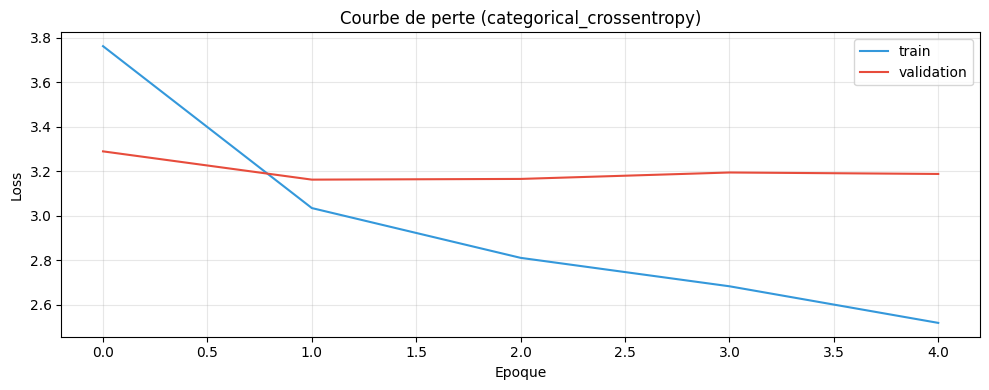

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='train', color='#3498db')
ax.plot(history.history['val_loss'], label='validation', color='#e74c3c')
ax.set_title('Courbe de perte (categorical_crossentropy)')
ax.set_xlabel('Epoque'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'l3_courbe_loss.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Evaluation (BLEU-1 / BLEU-2)

**QUOI** - Generer des legendes sur la validation et mesurer leur qualite par BLEU.
**POURQUOI** - Le **BLEU** compare les n-grammes generes aux legendes de reference
(plusieurs par image). BLEU-1 mesure la justesse des mots, BLEU-2 la coherence des
bigrammes.
**COMMENT** - Decodage glouton (*greedy*) mot a mot jusqu'a `<end>`, puis
`corpus_bleu` (nltk) avec lissage, et 8 exemples qualitatifs.

In [17]:
# Decodage glouton : on predit le mot le plus probable a chaque pas jusqu'a <end>
def generate_caption(model, feature, max_len=MAX_LEN):
    seq = [word2idx[START_TOK]]
    for _ in range(max_len):
        padded = pad_sequences([seq], maxlen=max_len, padding='post')
        yhat = model.predict([feature[None, :], padded], verbose=0)
        nxt = int(np.argmax(yhat[0]))
        if nxt == word2idx[END_TOK]:
            break
        seq.append(nxt)
    words = [idx2word[i] for i in seq[1:]
             if i not in (word2idx[START_TOK], word2idx[END_TOK], word2idx[PAD_TOK])]
    return words

# References : toutes les legendes nettoyees de chaque image de validation
val_refs = (val_df.groupby('file_name')['clean']
            .apply(lambda s: [c.split() for c in s]).to_dict())
print('Images de validation disponibles :', len(val_refs))

Images de validation disponibles : 1600


In [18]:
# Calcul du BLEU sur un sous-ensemble d'images de validation
eval_files = list(val_refs.keys())[:N_EVAL_IMAGES]
references, hypotheses = [], []

for fn in tqdm(eval_files, desc='Evaluation BLEU'):
    references.append(val_refs[fn])                         # listes de tokens de reference
    hypotheses.append(generate_caption(caption_model, features[fn]))

smooth = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0),       smoothing_function=smooth)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0),   smoothing_function=smooth)

print('Images evaluees :', len(eval_files))
print('BLEU-1 : %.4f' % bleu1)
print('BLEU-2 : %.4f' % bleu2)

Evaluation BLEU: 100%|██████████| 300/300 [07:01<00:00,  1.41s/it]


Images evaluees : 300
BLEU-1 : 0.5934
BLEU-2 : 0.3890


**Exemples qualitatifs** : 8 images avec la legende generee et une legende de reference.

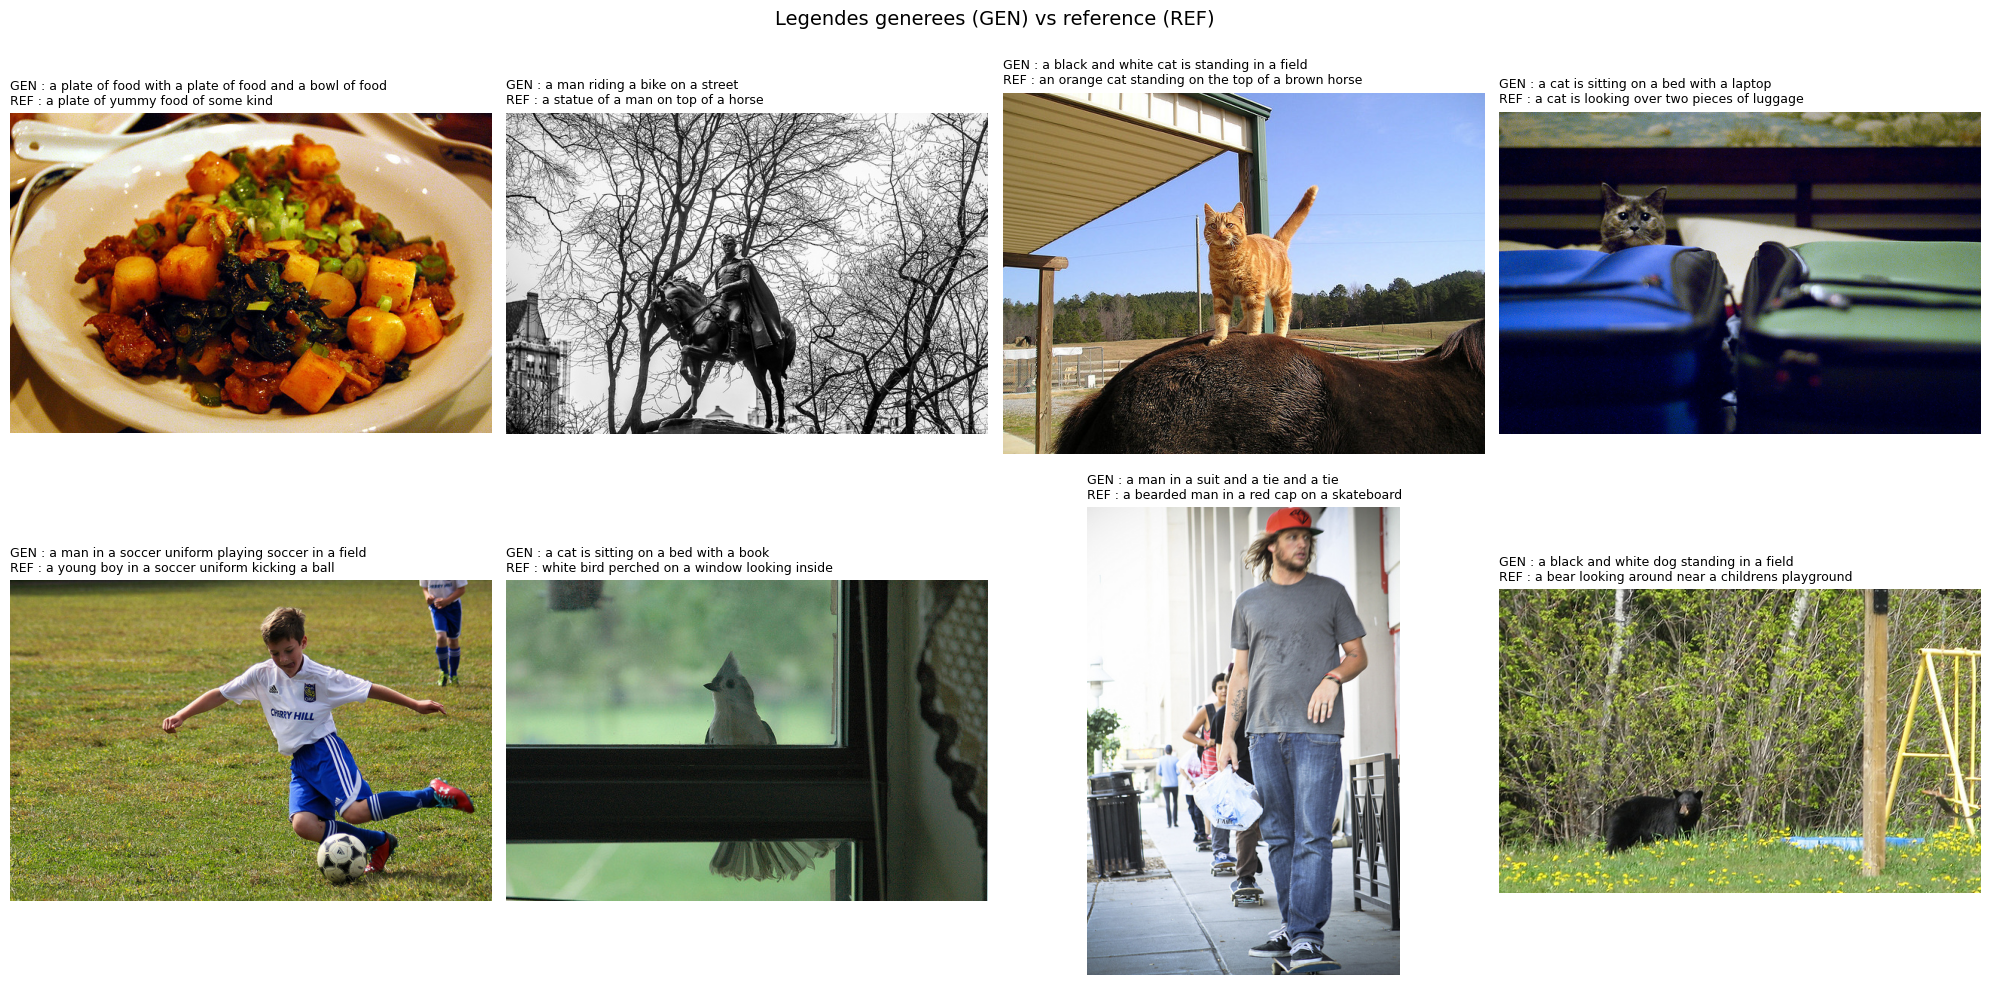

In [19]:
show_files = eval_files[:N_SHOW]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, fn in zip(axes.ravel(), show_files):
    ax.imshow(Image.open(IMAGES_DIR / fn)); ax.axis('off')
    gen = ' '.join(generate_caption(caption_model, features[fn]))
    ref = ' '.join(val_refs[fn][0])
    ax.set_title('GEN : %s\nREF : %s' % (gen, ref), fontsize=9, loc='left')
plt.suptitle('Legendes generees (GEN) vs reference (REF)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'l3_exemples_captions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Integration du workflow complet (L1 + L2 + L3)

**QUOI** - Enchainer les trois livrables sur une image : classification (L1),
debruitage (L2), captioning (L3).
**POURQUOI** - C'est l'objectif final de TouNum : produire automatiquement une
metadonnee (legende) a partir d'une image numerisee, en passant par les etapes de tri
et de nettoyage.
**COMMENT** - Chargement *defensif* des modeles L1 et L2 (s'ils existent), puis une
fonction `run_pipeline()` qui orchestre les trois etapes. Si un modele est absent,
l'etape est neutralisee proprement.

In [20]:
# Chargement defensif des modeles des livrables precedents
l1_model = None
if L1_MODEL_PATH.exists():
    try:
        l1_model = load_model(L1_MODEL_PATH)
        print('L1 (classification) charge :', L1_MODEL_PATH.name)
    except Exception as e:
        print('L1 non chargeable :', e)
else:
    print('L1 absent (', L1_MODEL_PATH.name, ') -> etape classification neutralisee.')

l2_model = None
if L2_MODEL_PATH.exists():
    try:
        # compile=False : on charge uniquement pour l'inference (perte custom MSE+SSIM)
        l2_model = load_model(L2_MODEL_PATH, compile=False)
        print('L2 (debruitage) charge     :', L2_MODEL_PATH.name)
    except Exception as e:
        print('L2 non chargeable (probable incompatibilite de version Keras :')
        print('  modele .keras sauve avec Keras 3 / TF>=2.13, env actuel = TF', tf.__version__, ') ->', e)
        print('  -> etape debruitage neutralisee (l image originale est utilisee).')
else:
    print('L2 absent -> etape debruitage neutralisee.')

L1 (classification) charge : cnn_scratch.keras
L2 (debruitage) charge     : unet_model_tf210.h5


> **Compatibilite du modele de debruitage (L2).** Le U-Net du livrable 2 a ete entraine
> et sauvegarde sous **Keras 3** (format `.keras` base sur un zip), que l'environnement de
> demonstration **TensorFlow 2.10 / Keras 2.10** ne sait pas relire (`file signature not found`).
> Le modele a donc ete **reconstruit a l'identique** en Keras 2.10 (memes couches, memes poids
> charges par nom) puis re-enregistre au format **HDF5 natif** `notebooks/unet_model_tf210.h5`
> (sorties numeriquement identiques a l'original, ecart < 1e-6). La cellule ci-dessus charge
> automatiquement cette version : **re-executer le workflow active le debruitage reel**.

In [21]:
# --- Helpers des trois etapes (robustes a l'absence de modele) ---

def classify_image(pil_img):
    "L1 : renvoie ('Photo'/'Non-Photo', proba) ; suppose Photo si modele absent."
    if l1_model is None:
        return 'Photo (defaut)', None
    arr = img_to_array(pil_img.resize((224, 224))) / 255.0
    p = float(l1_model.predict(arr[None, ...], verbose=0).ravel()[0])
    return ('Photo' if p >= 0.5 else 'Non-Photo'), p

def denoise_image(pil_img):
    "L2 : renvoie l'image debruitee (PIL) ; renvoie l'originale si modele absent."
    if l2_model is None:
        return pil_img
    arr = img_to_array(pil_img.resize((256, 256))) / 255.0
    out = l2_model.predict(arr[None, ...], verbose=0)[0]
    out = np.clip(out, 0, 1)
    return Image.fromarray((out * 255).astype('uint8'))

def caption_image(pil_img):
    "L3 : extrait les features puis genere la legende."
    arr = preprocess_input(img_to_array(pil_img.resize((IMG_SIZE, IMG_SIZE))))
    feat = encoder.predict(arr[None, ...], verbose=0)[0]
    return ' '.join(generate_caption(caption_model, feat))

def run_pipeline(image_path, verbose=True):
    "Orchestration L1 -> L2 -> L3 sur une image."
    img = Image.open(image_path).convert('RGB')
    label, proba = classify_image(img)          # L1
    denoised     = denoise_image(img)           # L2
    caption      = caption_image(denoised)      # L3 (sur l'image nettoyee)
    if verbose:
        print('Image    :', os.path.basename(str(image_path)))
        print('L1 classe:', label, ('(p=%.2f)' % proba) if proba is not None else '')
        print('L3 legende:', caption)
    return {'label': label, 'proba': proba, 'caption': caption,
            'image': img, 'denoised': denoised}

In [22]:
# Demonstration du workflow complet sur une image de validation
demo_file = eval_files[0]
res = run_pipeline(IMAGES_DIR / demo_file)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(res['image']);    axes[0].axis('off'); axes[0].set_title('Originale (L1: %s)' % res['label'])
axes[1].imshow(res['denoised']); axes[1].axis('off'); axes[1].set_title('Apres L2 (debruitage)')
plt.suptitle('Workflow TouNum  ->  L3 : "%s"' % res['caption'], fontsize=13)
plt.tight_layout(); plt.show()

NotFoundError: Graph execution error:

Detected at node 'unet_denoise/conv2d_transpose_20/conv2d_transpose' defined at (most recent call last):
    File "C:\Users\matis\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "C:\Users\matis\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "c:\Users\matis\envs\tf-gpu\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\Users\matis\envs\tf-gpu\lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
      app.start()
    File "c:\Users\matis\envs\tf-gpu\lib\site-packages\ipykernel\kernelapp.py", line 758, in start
      self.io_loop.start()
    File "c:\Users\matis\envs\tf-gpu\lib\site-packages\tornado\platform\asyncio.py", line 211, in start
      self.asyncio_loop.run_forever()
    File "C:\Users\matis\

---
## 10. Limites et pistes d'amelioration

**Limites du modele actuel**

- **Sous-echantillon reduit** (8000 images) : MS COCO complet contient ~83 000 images ;
  le vocabulaire et la diversite des scenes sont donc limites.
- **Encodeur gele** : InceptionV3 n'est pas affine sur le domaine TouNum (peintures,
  schemas, croquis) ; ses features sont generiques ImageNet.
- **Decodage glouton** : on choisit a chaque pas le mot le plus probable, ce qui peut
  produire des legendes repetitives ou sous-optimales.
- **BLEU** : metrique de surface (n-grammes) qui ne capture ni le sens ni la
  pertinence visuelle reelle.
- **Pas d'attention** : le modele *merge* resume l'image en un seul vecteur, sans se
  focaliser sur les regions pertinentes au fil de la generation.

**Pistes d'amelioration**

| Piste | Benefice attendu |
|-------|------------------|
| Augmenter le sous-echantillon (20k+ images) | meilleure couverture du vocabulaire |
| **Beam search** au decodage | legendes plus fluides et globalement coherentes |
| Mecanisme d'**attention** (Show, Attend & Tell) | focalisation spatiale, meilleur BLEU |
| **Fine-tuning** de l'encodeur sur le domaine TouNum | features adaptees aux non-photos |
| Embeddings pre-entraines (GloVe) | meilleure semantique des mots rares |
| Metriques complementaires (METEOR, CIDEr) | evaluation plus proche du jugement humain |
| Architecture **Transformer** (encodeur-decodeur) | etat de l'art en captioning |

**Conclusion** - Ce livrable demontre une chaine complete et fonctionnelle de
captioning integree au workflow TouNum (L1 + L2 + L3). Les pistes ci-dessus
permettraient d'en augmenter significativement la qualite pour un passage en production.